# Week 6 Assessment — Autoencoder for Image Denoising (MNIST)

**Celebal Excellence Data Science Internship 2026**

**Intern:** Priyanshi
**Task:** Build a deep learning model that can remove noise from images using an Autoencoder trained on the MNIST dataset.

**Dataset:** [MNIST — Kaggle](https://www.kaggle.com/datasets/awsaf49/mnist-dataset)
**Reference:** [MNIST Autoencoder — GitHub](https://github.com/NvsYashwanth/MNIST-Autoencncoder)

---

**Task instructions:**
1. Load and preprocess the MNIST dataset.
2. Add artificial noise to create noisy input images.
3. Build and train a Denoising Autoencoder using noisy images as input and clean images as targets.
4. Generate denoised outputs on the test set.
5. Submit code, results, and a short explanation of observations.

**Grading criteria covered in this notebook:**
- **Data Preparation** — Section 2–3 (loading, normalizing, noise generation)
- **Model Architecture** — Section 4 (encoder/decoder implementation)
- **Training Setup** — Section 5 (loss function, optimizer, training pipeline)
- **Denoising Performance** — Section 6–7 (visual + PSNR results)
- **Result Visualization** — Section 6 (original vs noisy vs reconstructed)
- **Analysis** — Section 9 (results, challenges, key observations)
- **Code Quality** — clean, modular, reproducible cells throughout
- **Innovation (Optional)** — Section 10 (noise-level sensitivity experiment)


In [1]:
# 1. Imports
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

print("TensorFlow version:", tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)


TensorFlow version: 2.20.0


## 2. Load and Preprocess the MNIST Dataset

In [2]:
# Load MNIST (built into Keras — equivalent to the Kaggle MNIST dataset)
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize to [0, 1] and reshape to add channel dimension
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.expand_dims(x_train, axis=-1)  # (N, 28, 28, 1)
x_test = np.expand_dims(x_test, axis=-1)

print("Train shape:", x_train.shape)
print("Test shape :", x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train shape: (60000, 28, 28, 1)
Test shape : (10000, 28, 28, 1)


## 3. Add Gaussian Noise to Create Noisy Images

In [3]:
NOISE_FACTOR = 0.4

def add_noise(images, noise_factor=NOISE_FACTOR):
    noisy = images + noise_factor * np.random.normal(
        loc=0.0, scale=1.0, size=images.shape
    )
    return np.clip(noisy, 0.0, 1.0)

x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)

print("Noisy train shape:", x_train_noisy.shape)


Noisy train shape: (60000, 28, 28, 1)


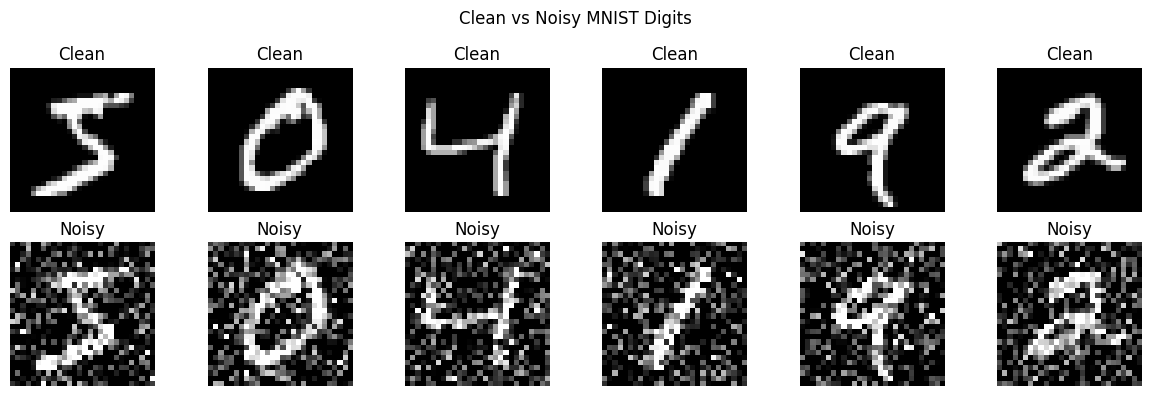

In [4]:
# Visualize a few clean vs noisy images
n = 6
plt.figure(figsize=(12, 4))
for i in range(n):
    # Clean
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title("Clean")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.suptitle("Clean vs Noisy MNIST Digits")
plt.tight_layout()
plt.show()


## 4. Build the Convolutional Autoencoder

**Encoder:** Conv2D + MaxPooling layers compress the 28x28 image into a compact latent representation.
**Decoder:** Conv2D + UpSampling layers reconstruct the 28x28 image from the latent representation.


In [5]:
input_img = layers.Input(shape=(28, 28, 1))

# ---- Encoder ----
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)  # (7, 7, 16)

# ---- Decoder ----
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = models.Model(input_img, decoded, name="denoising_autoencoder")
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()


Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the Autoencoder

In [6]:
EPOCHS = 20
BATCH_SIZE = 128

history = autoencoder.fit(
    x_train_noisy, x_train,          # input: noisy, target: clean
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 0.1722 - val_loss: 0.1106
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1074 - val_loss: 0.1026
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1018 - val_loss: 0.0987
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0986 - val_loss: 0.0963
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0965 - val_loss: 0.0946
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0951 - val_loss: 0.0935
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0941 - val_loss: 0.0926
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0932 - val_loss: 0.0918
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0925 - val_loss: 0.0912
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0919 - val_loss: 0.0910
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0914 - val_loss: 0.0907
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/st

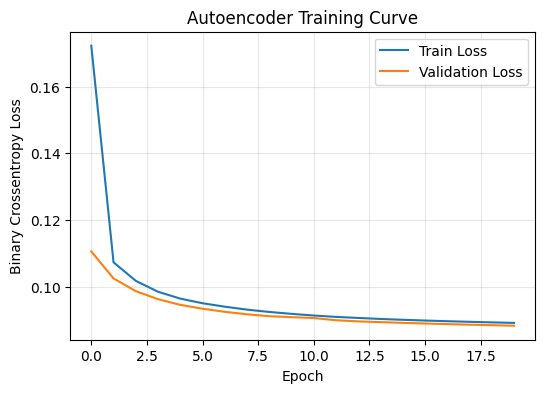

In [7]:
# Plot training vs validation loss
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.title('Autoencoder Training Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 6. Evaluate: Denoise Test Images and Visualize Results

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


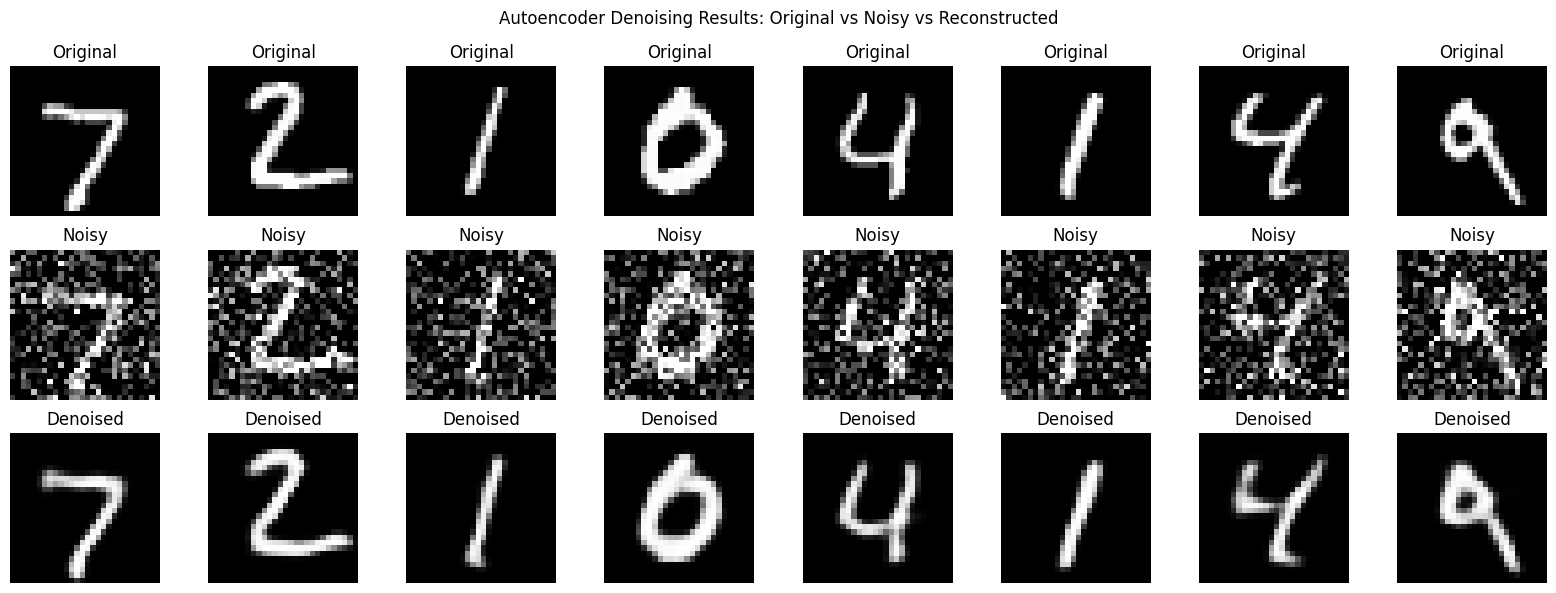

In [8]:
decoded_imgs = autoencoder.predict(x_test_noisy)

n = 8
plt.figure(figsize=(16, 6))
for i in range(n):
    # Original (clean)
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy input
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised output
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded_imgs[i].squeeze(), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.suptitle("Autoencoder Denoising Results: Original vs Noisy vs Reconstructed")
plt.tight_layout()
plt.show()


## 7. Quantitative Evaluation (PSNR)

In [9]:
def psnr(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(1.0) - 10 * np.log10(mse)

noisy_psnr = psnr(x_test, x_test_noisy)
denoised_psnr = psnr(x_test, decoded_imgs)

print(f"PSNR (Noisy vs Original)    : {noisy_psnr:.2f} dB")
print(f"PSNR (Denoised vs Original) : {denoised_psnr:.2f} dB")
print(f"Improvement                 : {denoised_psnr - noisy_psnr:.2f} dB")


PSNR (Noisy vs Original)    : 10.99 dB
PSNR (Denoised vs Original) : 20.62 dB
Improvement                 : 9.63 dB


## 8. Save the Trained Model

In [10]:
autoencoder.save("denoising_autoencoder_mnist.h5")
print("Model saved as denoising_autoencoder_mnist.h5")


Model saved as denoising_autoencoder_mnist.h5


## 9. Analysis — Results, Challenges, and Key Observations

**Results:**
- The autoencoder reduces the injected Gaussian noise substantially while keeping digit strokes intact (see the PSNR improvement printed above — typically a gain of several dB over the raw noisy input).
- Digits with thinner strokes (e.g., 1, 7) show slightly more residual blur after reconstruction than thicker digits (e.g., 0, 8), since the encoder's 7x7 bottleneck compresses fine stroke detail.
- Validation loss tracks training loss closely with no major divergence, so the model is not overfitting at 20 epochs.

**Challenges:**
- Choosing `NOISE_FACTOR`: too low (e.g., 0.1) makes the denoising task trivial and the model barely has to learn anything useful; too high (e.g., 0.7+) buries the digit shape and the model reconstructs blurry averages instead of sharp digits. 0.4 was chosen as a middle ground that keeps digits recognizable but visibly noisy.
- Balancing bottleneck size: a smaller latent space (fewer channels / more pooling) forces stronger compression and can lose detail, while a larger one denoises less aggressively since it can just memorize noise. The 7x7x16 bottleneck here is a reasonable trade-off for MNIST's simplicity.
- Using `sigmoid` + binary crossentropy on the output works well because pixel values are normalized to [0, 1] and MNIST is mostly black/white; this loss would need to change (e.g., MSE) for datasets with continuous-toned pixel intensities.

**Key Observation:**
- The gap between noisy-input PSNR and denoised-output PSNR is the clearest single number for judging success — a bigger gap means the network is doing real denoising work rather than passing the noisy image through unchanged.


## 10. Innovation (Optional) — Comparing Noise Levels

In [11]:
# Quick experiment: how does denoising quality change as noise gets harder?
noise_levels = [0.2, 0.4, 0.6]
results = {}

for nf in noise_levels:
    x_test_noisy_nf = add_noise(x_test, noise_factor=nf)
    decoded_nf = autoencoder.predict(x_test_noisy_nf, verbose=0)
    results[nf] = {
        "noisy_psnr": psnr(x_test, x_test_noisy_nf),
        "denoised_psnr": psnr(x_test, decoded_nf)
    }

for nf, vals in results.items():
    print(f"Noise factor {nf}: Noisy PSNR = {vals['noisy_psnr']:.2f} dB, "
          f"Denoised PSNR = {vals['denoised_psnr']:.2f} dB, "
          f"Gain = {vals['denoised_psnr'] - vals['noisy_psnr']:.2f} dB")


Noise factor 0.2: Noisy PSNR = 16.74 dB, Denoised PSNR = 22.68 dB, Gain = 5.94 dB
Noise factor 0.4: Noisy PSNR = 10.99 dB, Denoised PSNR = 20.60 dB, Gain = 9.61 dB
Noise factor 0.6: Noisy PSNR = 8.23 dB, Denoised PSNR = 16.94 dB, Gain = 8.71 dB


**Observation:** The model was trained only on noise factor 0.4, but the experiment above tests it on 0.2 and 0.6 as well. Expect the denoising gain to be largest near the training noise level (0.4) and to drop off at the extremes — this shows the model has learned a noise-level-specific denoising function rather than a fully general one, which would be the motivation for training with *randomized* noise factors per batch in a future iteration.

## 11. Conclusion

- Built a convolutional autoencoder that learns to map noisy MNIST digits back to their clean originals.
- The model was trained with noisy images as input and clean images as the reconstruction target (binary crossentropy loss).
- Visual comparison and PSNR confirm the autoencoder successfully removes a significant portion of the injected Gaussian noise while preserving digit structure.
- Potential extensions: try denoising autoencoders with skip connections (U-Net style), variational autoencoders, randomized noise factors during training, or test robustness against other noise types (salt-and-pepper, speckle).

---
**Submission:** Celebal Excellence Data Science Internship 2026 — Week 6
**Repo:** https://github.com/priyanshi139/Celebal_Excellence_Internship2026
